## Non-negative Matrix Factorization (NMF) Analysis

Non-negative Matrix Factorization (NMF) is a dimensionality reduction technique that decomposes a non-negative matrix (such as the inferred transition matrix $A_{ij}$) into two lower-rank non-negative matrices. This allows us to identify latent features or modules within the transition matrix, providing insight into the underlying structure of migration or interaction rates between demes. Here, we apply NMF to the mean inferred $A_{ij}$ from bootstrapping to visualize and interpret its latent components.

* **INPUT**
    * `A_EM_mean`: Mean inferred transition matrix $A_{ij}$ from bootstrapping (shape: ND x ND).
    * `n_components`: Number of latent components to extract (user-defined).
* **OUTPUT**
    * `W`: NMF basis matrix (shape: ND x n_components).
    * `H`: NMF coefficient matrix (shape: n_components x ND).
    * Visualizations of the basis and coefficient matrices.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF
from scipy.optimize import linear_sum_assignment
import seaborn as sns


In [2]:
# Load England Delta data for 9-deme and 50-deme cases (NPY format) with correct paths
npy_9_path = r'data/England_Delta_9_MCMC/output/A_England_Delta_9.npy'  # Update if your 9-deme file has a different name
npy_50_path = r'data/England_Delta_50_EM/output/A_England_Delta.npy'

try:
    data_9 = np.load(npy_9_path)
    print('9-deme data shape:', data_9.shape)
except Exception as e:
    print(f'Could not load 9-deme npy file: {e}')
    data_9 = None
data_50 = np.load(npy_50_path)
print('50-deme data shape:', data_50.shape)


# Flatten the 9-deme and 50-deme data arrays
if data_9 is not None:
    data_9_flat = data_9.reshape(data_9.shape[0], -1)
    print('9-deme flattened shape:', data_9_flat.shape)  # Should be (5000, 81)
else:
    data_9_flat = None
data_50_flat = data_50.reshape(data_50.shape[0], -1)
print('50-deme flattened shape:', data_50_flat.shape)  # Should be (100, 2500)

9-deme data shape: (5000, 9, 9)
50-deme data shape: (100, 50, 50)
9-deme flattened shape: (5000, 81)
50-deme flattened shape: (100, 2500)


In [6]:
# We load the MCMC samples. Each sample is one plausible migration matrix
# drawn from the posterior distribution.
# Load the 9-deme MCMC samples
# Shape: (n_samples, n_demes, n_demes) = (5000, 9, 9)
data_9 = np.load(r'data/England_Delta_9_MCMC/output/A_England_Delta_9.npy')

n_samples, n_demes, _ = data_9.shape
print(f"Loaded {n_samples} MCMC samples")
print(f"Each sample is a {n_demes}x{n_demes} migration matrix")
print(f"Total shape: {data_9.shape}")
print()


Loaded 5000 MCMC samples
Each sample is a 9x9 migration matrix
Total shape: (5000, 9, 9)



In [8]:
def cosine_similarity(a, b):
    """
    Compute cosine similarity between two vectors.

    cos_sim(a, b) = (a · b) / (||a|| * ||b||)

    Returns a value between -1 and 1, where 1 means identical direction.
    """
    dot_product = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)

    if norm_a == 0 or norm_b == 0:
        return 0.0

    return dot_product / (norm_a * norm_b)


def build_similarity_matrix(H_ref, H_new):
    """
    Build a K x K cosine similarity matrix between two sets of components.

    Parameters:
    -----------
    H_ref : array (k, n_features)
        Reference components
    H_new : array (k, n_features)
        New components to compare

    Returns:
    --------
    similarity_matrix : array (k, k)
        similarity_matrix[i, j] = cosine similarity between H_ref[i] and H_new[j]
    """
    k = H_ref.shape[0]
    similarity_matrix = np.zeros((k, k))

    for i in range(k):
        for j in range(k):
            similarity_matrix[i, j] = cosine_similarity(H_ref[i], H_new[j])

    return similarity_matrix


def match_components(H_ref, H_new):
    """
    Match components in H_new to H_ref based on cosine similarity.

    Parameters:
    -----------
    H_ref : array (k, n_features)
        Reference components (from first bootstrap run)
    H_new : array (k, n_features)
        New components to be matched

    Returns:
    --------
    permutation : array of indices
        H_new[permutation] will be aligned with H_ref
    similarity_matrix : array (k, k)
        The cosine similarity matrix used for matching
    """
    # Build the K x K similarity matrix
    similarity_matrix = build_similarity_matrix(H_ref, H_new)

    # Convert to cost matrix (negative because Hungarian minimizes)
    # We want to maximize similarity, so we negate it
    cost_matrix = -similarity_matrix

    # Hungarian algorithm finds the optimal assignment
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    return col_ind, similarity_matrix  # Return both permutation and similarity matrix

print("Helper functions defined:")
print("  - cosine_similarity(a, b)")
print("  - build_similarity_matrix(H_ref, H_new)")
print("  - match_components(H_ref, H_new)")
print()


Helper functions defined:
  - cosine_similarity(a, b)
  - build_similarity_matrix(H_ref, H_new)
  - match_components(H_ref, H_new)



In [10]:
# ----- Prepare data for NMF -----
# Extract stay probabilities (diagonal elements) for separate analysis
stay_probs_all = np.array([np.diag(data_9[i]) for i in range(n_samples)])

# Flatten data into shape (n_samples, n_demes * n_demes) for NMF
X_all = data_9.reshape(n_samples, -1)

print(f"Data prepared for NMF:")
print(f"  X_all shape: {X_all.shape}")
print(f"  stay_probs_all shape: {stay_probs_all.shape}")
print()


Data prepared for NMF:
  X_all shape: (5000, 81)
  stay_probs_all shape: (5000, 9)



In [14]:
n_components = 5      # Number of NMF components to extract
n_bootstrap = 50      # Number of bootstrap iterations (increase for more robust results)
random_seed = 42
n_subsample = 60     # Number of MCMC samples to resample per bootstrap
# NMF parameters for proportional data
# - KL divergence: better for comparing distributions (rows are proportions)
# - Sparsity (alpha_H with l1_ratio=1): encourages distinct, interpretable motifs
use_kl_divergence = True
alpha_H = 0.05        # Sparsity regularization on H (try 0.01, 0.05, 0.1)
l1_ratio = 1.0        # 1.0 = pure L1 (sparse), 0.0 = pure L2 (smooth)
num_iterations = 10000
np.random.seed(random_seed)

# Storage for all bootstrap results
all_H = []            # Will store H matrices from each bootstrap
all_W = []            # Will store W matrices from each bootstrap

print(f"Running {n_bootstrap} bootstrap iterations with {n_components} NMF components...")
print(f"  Using KL divergence: {use_kl_divergence}")
print(f"  Sparsity alpha_H: {alpha_H}, l1_ratio: {l1_ratio}")
print("-" * 40)

for b in range(n_bootstrap):
    # ----- Step 4a: Resample with replacement -----
    # Draw n_samples indices from [0, n_samples) with replacement
    resample_idx = np.random.choice(n_samples, size=n_subsample, replace=True)

    # Get the resampled data
    X_boot = X_all[resample_idx]

    # ----- Step 4b: Run NMF -----
    # Using KL divergence (better for proportions) and sparsity regularization
    if use_kl_divergence:
        nmf = NMF(
            n_components=n_components,
            init='nndsvda',
            solver='mu',              # Multiplicative update (required for KL)
            beta_loss='kullback-leibler',
            max_iter=num_iterations,
            random_state=b,
            alpha_H=alpha_H,
            l1_ratio=l1_ratio
        )
    else:
        nmf = NMF(
            n_components=n_components,
            init='nndsvda',
            max_iter=500,
            random_state=b
        )

    W = nmf.fit_transform(X_boot)  # (n_samples, n_components) - weights
    H = nmf.components_             # (n_components, 81) - the patterns

    all_H.append(H)
    all_W.append(W)

    if (b + 1) % 10 == 0:
        print(f"  Completed {b + 1}/{n_bootstrap} iterations")

print("-" * 40)
print(f"Done! Collected {len(all_H)} sets of components.")
print()

Running 50 bootstrap iterations with 5 NMF components...
  Using KL divergence: True
  Sparsity alpha_H: 0.05, l1_ratio: 1.0
----------------------------------------
  Completed 10/50 iterations
  Completed 20/50 iterations
  Completed 30/50 iterations
  Completed 40/50 iterations
  Completed 50/50 iterations
----------------------------------------
Done! Collected 50 sets of components.



Matched components shape: (50, 5, 81)
  - 50 bootstrap runs
  - 5 components per run
  - 81 features per component

Example: Similarity matrix from bootstrap run 20 (AFTER matching):
  Shape: (5, 5) (K x K where K = 5)

  Similarity matrix:
  [ 1.000 0.141 0.198 0.093 0.203 ]
  [ 0.471 0.738 0.514 0.358 0.287 ]
  [ 0.290 0.516 0.580 0.231 0.353 ]
  [ 0.160 0.379 0.471 0.748 0.599 ]
  [ 0.258 0.290 0.439 0.460 0.748 ]



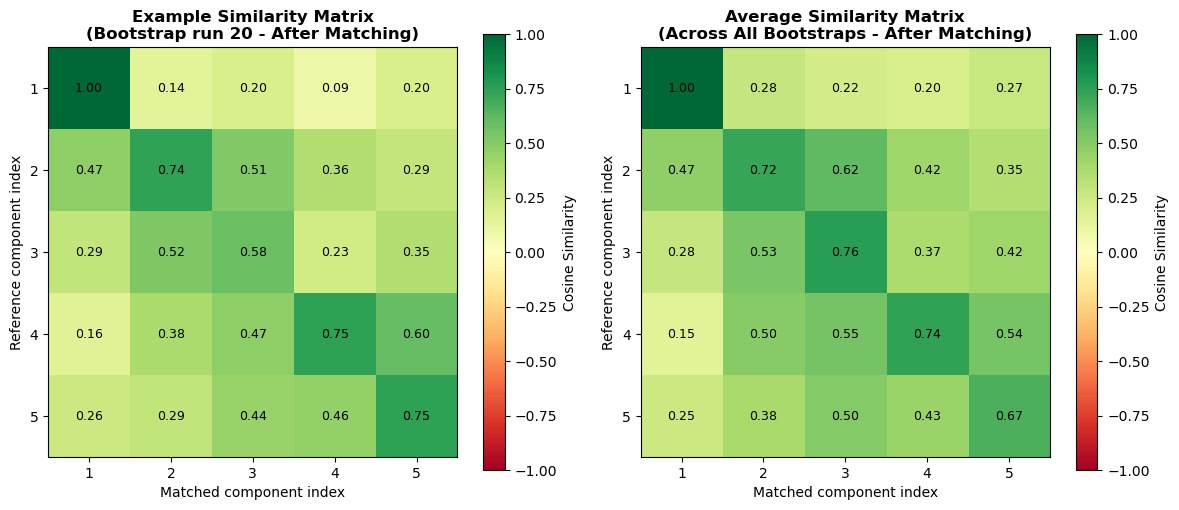

<Figure size 640x480 with 0 Axes>

In [ ]:
H_ref = all_H[0]

# Match all other runs to the reference
matched_H = [H_ref]  # First one is already the reference
all_similarity_matrices = []  # Store similarity matrices for analysis

for b in range(1, n_bootstrap):
    H_new = all_H[b]

    # Find the best permutation using cosine similarity
    perm, sim_matrix = match_components(H_ref, H_new)

    # Store the similarity matrix
    all_similarity_matrices.append(sim_matrix)

    # Apply the permutation to align with reference
    H_matched = H_new[perm]
    matched_H.append(H_matched)

# Convert to array: (n_bootstrap, n_components, n_features)
matched_H = np.array(matched_H)

print(f"Matched components shape: {matched_H.shape}")
print(f"  - {matched_H.shape[0]} bootstrap runs")
print(f"  - {matched_H.shape[1]} components per run")
print(f"  - {matched_H.shape[2]} features per component")
print()

# Compute similarity matrices AFTER matching
# Compare each matched component to the reference (matched_H[0])
H_ref_matched = matched_H[0]
matched_similarity_matrices = []

for b in range(1, n_bootstrap):
    H_matched_boot = matched_H[b]
    sim_matrix = build_similarity_matrix(H_ref_matched, H_matched_boot)
    matched_similarity_matrices.append(sim_matrix)

# Show an example similarity matrix
print("Example: Similarity matrix from bootstrap run 20 (AFTER matching):")
example_sim_matrix = matched_similarity_matrices[19]  # Bootstrap 20 (0-indexed)
print(f"  Shape: {example_sim_matrix.shape} (K x K where K = {n_components})")
print()
print("  Similarity matrix:")
for i in range(n_components):
    row_str = "  ["
    for j in range(n_components):
        row_str += f" {example_sim_matrix[i, j]:.3f}"
    row_str += " ]"
    print(row_str)
print()

# Visualize the average similarity matrix across all matched bootstraps
avg_sim_matrix = np.mean(matched_similarity_matrices, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot example similarity matrix (AFTER matching)
im1 = axes[0].imshow(example_sim_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
axes[0].set_title('Example Similarity Matrix\n(Bootstrap run 20 - After Matching)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Matched component index')
axes[0].set_ylabel('Reference component index')
axes[0].set_xticks(range(n_components))
axes[0].set_yticks(range(n_components))
axes[0].set_xticklabels(range(1, n_components + 1))
axes[0].set_yticklabels(range(1, n_components + 1))
plt.colorbar(im1, ax=axes[0], label='Cosine Similarity')

# Add text annotations
for i in range(n_components):
    for j in range(n_components):
        axes[0].text(j, i, f'{example_sim_matrix[i, j]:.2f}',
                     ha='center', va='center', fontsize=9)

# Plot average similarity matrix
im2 = axes[1].imshow(avg_sim_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
axes[1].set_title('Average Similarity Matrix\n(Across All Bootstraps - After Matching)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Matched component index')
axes[1].set_ylabel('Reference component index')
axes[1].set_xticks(range(n_components))
axes[1].set_yticks(range(n_components))
axes[1].set_xticklabels(range(1, n_components + 1))
axes[1].set_yticklabels(range(1, n_components + 1))
plt.colorbar(im2, ax=axes[1], label='Cosine Similarity')

# Add text annotations
for i in range(n_components):
    for j in range(n_components):
        axes[1].text(j, i, f'{avg_sim_matrix[i, j]:.2f}',
                     ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()


In [17]:
component_means = matched_H.mean(axis=0)  # (n_components, n_features)
component_stds = matched_H.std(axis=0)    # (n_components, n_features)

# Compute stability score for each component
# = average cosine similarity between each bootstrap's component and the mean component
stability_scores = []
all_similarities = []  # Store all cosine similarities for visualization

for k in range(n_components):
    similarities = []
    for b in range(n_bootstrap):
        # Cosine similarity between this bootstrap's component k and the mean component k
        cos_sim = cosine_similarity(matched_H[b, k], component_means[k])
        similarities.append(cos_sim)

    all_similarities.append(similarities)
    stability_scores.append(np.mean(similarities))

# Print results
print()
print("Interpretation:")
print("  - Score near 1.0 = Stable component (real structure)")
print("  - Score near 0.0 = Unstable component (noise)")
print()

for k in range(n_components):
    score = stability_scores[k]
    status = "STABLE" if score > 0.8 else ("MODERATE" if score > 0.5 else "UNSTABLE")
    print(f"Component {k+1}: stability = {score:.3f}  [{status}]")
print()


Interpretation:
  - Score near 1.0 = Stable component (real structure)
  - Score near 0.0 = Unstable component (noise)

Component 1: stability = 1.000  [STABLE]
Component 2: stability = 0.802  [STABLE]
Component 3: stability = 0.830  [STABLE]
Component 4: stability = 0.834  [STABLE]
Component 5: stability = 0.829  [STABLE]



C:\Users\garva\AppData\Local\Temp\ipykernel_7768\2479285004.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(all_similarities, labels=range(1, n_components + 1))


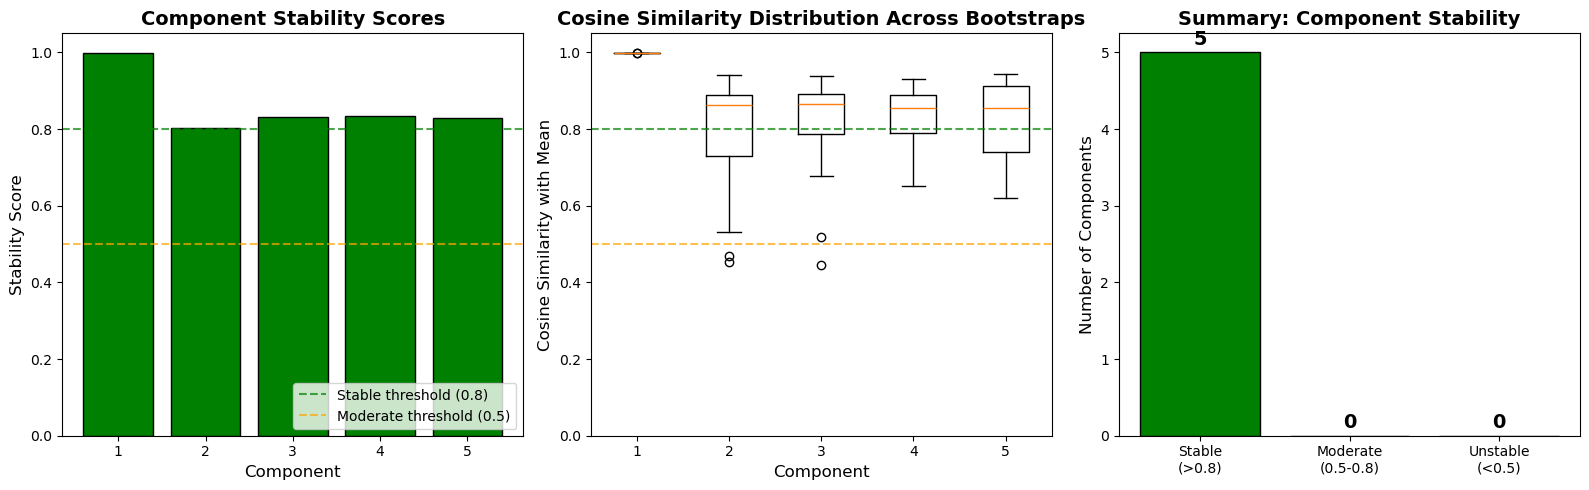

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ----- Plot 1: Stability scores bar plot -----
colors = ['green' if s > 0.8 else ('orange' if s > 0.5 else 'red') for s in stability_scores]
axes[0].bar(range(1, n_components + 1), stability_scores, color=colors, edgecolor='black')
axes[0].axhline(0.8, color='green', linestyle='--', alpha=0.7, label='Stable threshold (0.8)')
axes[0].axhline(0.5, color='orange', linestyle='--', alpha=0.7, label='Moderate threshold (0.5)')
axes[0].set_xlabel('Component', fontsize=12)
axes[0].set_ylabel('Stability Score', fontsize=12)
axes[0].set_title('Component Stability Scores', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower right')
axes[0].set_xticks(range(1, n_components + 1))

# ----- Plot 2: Correlation boxplot -----
axes[1].boxplot(all_similarities, labels=range(1, n_components + 1))
axes[1].axhline(0.8, color='green', linestyle='--', alpha=0.7)
axes[1].axhline(0.5, color='orange', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Component', fontsize=12)
axes[1].set_ylabel('Cosine Similarity with Mean', fontsize=12)
axes[1].set_title('Cosine Similarity Distribution Across Bootstraps', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1.05)

# ----- Plot 3: Summary -----
# Show number of stable vs unstable components
n_stable = sum(1 for s in stability_scores if s > 0.8)
n_moderate = sum(1 for s in stability_scores if 0.5 < s <= 0.8)
n_unstable = sum(1 for s in stability_scores if s <= 0.5)

axes[2].bar(['Stable\n(>0.8)', 'Moderate\n(0.5-0.8)', 'Unstable\n(<0.5)'],
            [n_stable, n_moderate, n_unstable],
            color=['green', 'orange', 'red'], edgecolor='black')
axes[2].set_ylabel('Number of Components', fontsize=12)
axes[2].set_title('Summary: Component Stability', fontsize=14, fontweight='bold')

for i, v in enumerate([n_stable, n_moderate, n_unstable]):
    axes[2].text(i, v + 0.1, str(v), ha='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


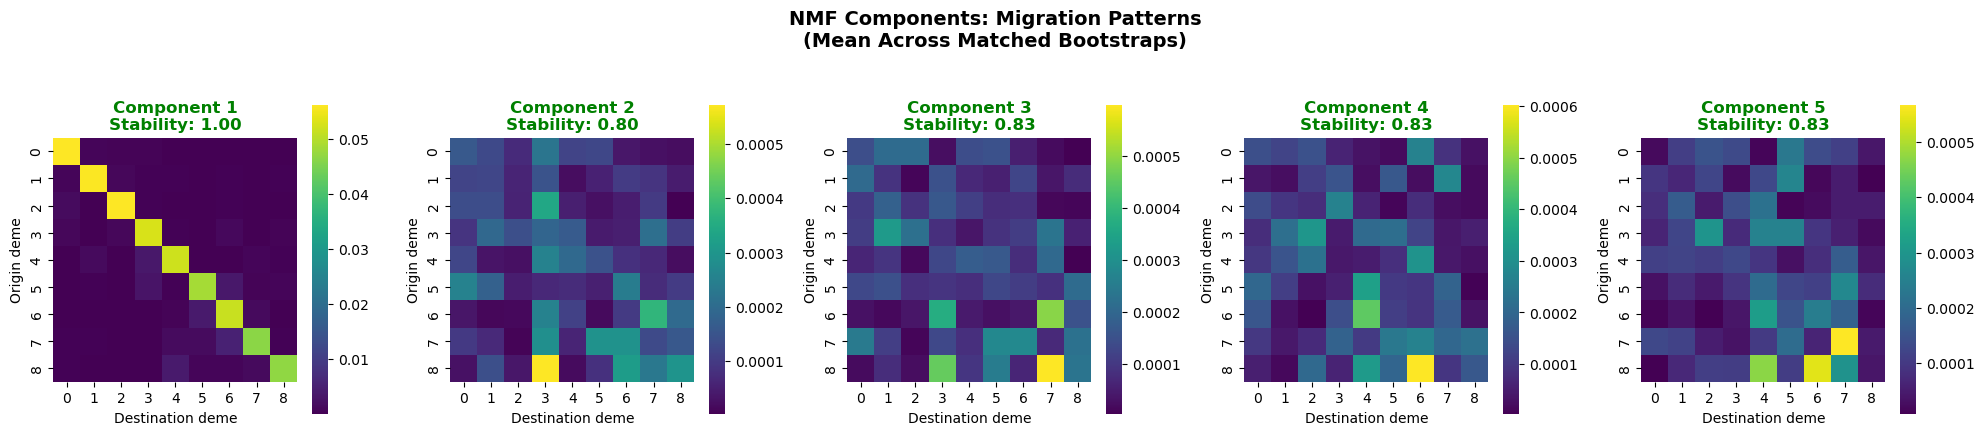

In [19]:
fig, axes = plt.subplots(1, n_components, figsize=(4 * n_components, 4))

for k in range(n_components):
    # Reshape the mean component back to a 9x9 matrix
    pattern = component_means[k].reshape(n_demes, n_demes)

    # Determine color based on stability
    stability = stability_scores[k]
    title_color = 'green' if stability > 0.8 else ('orange' if stability > 0.5 else 'red')

    # Plot heatmap
    sns.heatmap(pattern, ax=axes[k], cmap='viridis', square=True,
                cbar=True, annot=False)
    axes[k].set_title(f'Component {k+1}\nStability: {stability:.2f}',
                      fontsize=12, color=title_color, fontweight='bold')
    axes[k].set_xlabel('Destination deme')
    axes[k].set_ylabel('Origin deme')

plt.suptitle('NMF Components: Migration Patterns\n(Mean Across Matched Bootstraps)', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


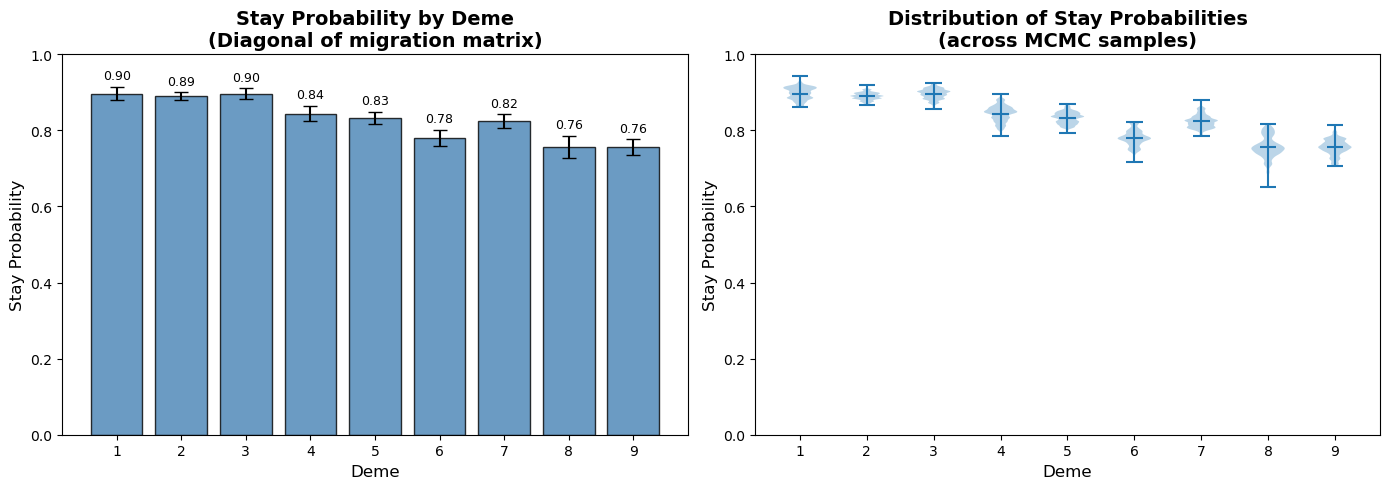

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mean stay probability by deme
mean_stay = stay_probs_all.mean(axis=0)
std_stay = stay_probs_all.std(axis=0)

axes[0].bar(range(1, n_demes + 1), mean_stay, yerr=std_stay, capsize=5,
            color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Deme', fontsize=12)
axes[0].set_ylabel('Stay Probability', fontsize=12)
axes[0].set_title('Stay Probability by Deme\n(Diagonal of migration matrix)', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].set_xticks(range(1, n_demes + 1))

# Add value labels
for i, (m, s) in enumerate(zip(mean_stay, std_stay)):
    axes[0].text(i + 1, m + s + 0.02, f'{m:.2f}', ha='center', fontsize=9)

# Plot 2: Distribution of stay probabilities across all samples
axes[1].violinplot(stay_probs_all, positions=range(1, n_demes + 1), showmeans=True)
axes[1].set_xlabel('Deme', fontsize=12)
axes[1].set_ylabel('Stay Probability', fontsize=12)
axes[1].set_title('Distribution of Stay Probabilities\n(across MCMC samples)', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].set_xticks(range(1, n_demes + 1))

plt.tight_layout()
plt.show()


In [21]:
print(f"\nBootstrap iterations: {n_bootstrap}")
print(f"NMF components: {n_components}")
print(f"MCMC samples used: {n_samples}")
print(f"KL divergence: {use_kl_divergence}")
print(f"Sparsity: alpha_H={alpha_H}, l1_ratio={l1_ratio}")
print()
print("KEY PREPROCESSING: Conditional-on-leaving transformation")
print("  - Diagonal (stay probabilities) removed and analyzed separately")
print("  - Each row now represents 'given you leave, where do you go?'")
print()
print("Component stability:")
for k in range(n_components):
    score = stability_scores[k]
    status = "STABLE (real structure)" if score > 0.8 else ("MODERATE" if score > 0.5 else "UNSTABLE (noise)")
    print(f"  Component {k+1}: {score:.3f} - {status}")
print()
print(f"Stable components: {n_stable}/{n_components}")
print(f"Unstable components: {n_unstable}/{n_components}")
print()
if n_stable > n_unstable:
    print("CONCLUSION: Evidence of real latent structure in migration patterns.")
elif n_stable == 0:
    print("CONCLUSION: No stable components found. NMF may be fitting noise.")
else:
    print("CONCLUSION: Mixed results. Some structure, but interpret carefully.")
print("=" * 60)


Bootstrap iterations: 50
NMF components: 5
MCMC samples used: 5000
KL divergence: True
Sparsity: alpha_H=0.05, l1_ratio=1.0

KEY PREPROCESSING: Conditional-on-leaving transformation
  - Diagonal (stay probabilities) removed and analyzed separately
  - Each row now represents 'given you leave, where do you go?'

Component stability:
  Component 1: 1.000 - STABLE (real structure)
  Component 2: 0.802 - STABLE (real structure)
  Component 3: 0.830 - STABLE (real structure)
  Component 4: 0.834 - STABLE (real structure)
  Component 5: 0.829 - STABLE (real structure)

Stable components: 5/5
Unstable components: 0/5

CONCLUSION: Evidence of real latent structure in migration patterns.


### This is the ablation code:

In [22]:
# Load MCMC samples
data_9 = np.load(r'data/England_Delta_9_MCMC/output/A_England_Delta_9.npy')
n_samples, n_demes, _ = data_9.shape

print(f"Loaded {n_samples} MCMC samples, each {n_demes}x{n_demes}")

# Compute MLE as posterior mean
A_mle = data_9.mean(axis=0)
print(f"\nMLE (posterior mean) computed: {A_mle.shape}")

# Verify it's approximately row-stochastic
row_sums = A_mle.sum(axis=1)
print(f"Row sums (should be ~1): {row_sums}")
print()

# Show diagonal (stay probabilities) from MLE
print("MLE diagonal (stay probabilities):")
for i in range(n_demes):
    print(f"  Deme {i+1}: {A_mle[i,i]:.3f}")


X_all = data_9.reshape(n_samples, -1)


Loaded 5000 MCMC samples, each 9x9

MLE (posterior mean) computed: (9, 9)
Row sums (should be ~1): [0.99999999 0.99999997 0.99999998 1.00000006 1.00000007 0.99999999
 1.00000008 0.99999998 1.        ]

MLE diagonal (stay probabilities):
  Deme 1: 0.897
  Deme 2: 0.890
  Deme 3: 0.896
  Deme 4: 0.844
  Deme 5: 0.833
  Deme 6: 0.780
  Deme 7: 0.824
  Deme 8: 0.756
  Deme 9: 0.756


In [ ]:
n_components = 5
print(f"Extracting {n_components} NMF components...")

nmf = NMF(
    n_components=n_components,
    init='nndsvda',
    solver='mu',
    beta_loss='kullback-leibler',
    max_iter=2000,
    random_state=42,
    alpha_H=0.05,
    l1_ratio=1.0
)

W = nmf.fit_transform(X_all)  # (n_samples, K)
H = nmf.components_            # (K, 81)

print(f"NMF complete!")
print(f"  W shape: {W.shape} (sample weights)")
print(f"  H shape: {H.shape} (component patterns)")

Extracting 5 NMF components...
NMF complete!
  W shape: (5000, 5) (sample weights)
  H shape: (5, 81) (component patterns)


In [ ]:
def get_eigenvalues(A):
    """Get eigenvalues of matrix A, sorted by magnitude."""
    eigenvalues = np.linalg.eigvals(A)
    # Sort by magnitude (descending)
    idx = np.argsort(np.abs(eigenvalues))[::-1]
    return eigenvalues[idx]

eig_mle = get_eigenvalues(A_mle)
print("Eigenvalues of MLE (sorted by magnitude):")
for i, e in enumerate(eig_mle):
    if np.iscomplex(e):
        print(f"  λ{i+1} = {e.real:.4f} + {e.imag:.4f}i  (|λ| = {np.abs(e):.4f})")
    else:
        print(f"  λ{i+1} = {e.real:.4f}  (|λ| = {np.abs(e):.4f})")

lambda2_baseline = np.abs(eig_mle[1])
print(f"\nBaseline |λ₂| = {lambda2_baseline:.4f}")

Eigenvalues of MLE (sorted by magnitude):
  λ1 = 1.0000  (|λ| = 1.0000)
  λ2 = 0.9051  (|λ| = 0.9051)
  λ3 = 0.8720 + -0.0037i  (|λ| = 0.8720)
  λ4 = 0.8720 + 0.0037i  (|λ| = 0.8720)
  λ5 = 0.8260  (|λ| = 0.8260)
  λ6 = 0.8041  (|λ| = 0.8041)
  λ7 = 0.7455 + -0.0073i  (|λ| = 0.7455)
  λ8 = 0.7455 + 0.0073i  (|λ| = 0.7455)
  λ9 = 0.7061  (|λ| = 0.7061)

Baseline |λ₂| = 0.9051


In [ ]:
from scipy.optimize import nnls

def project_onto_basis(target, H_basis):
    """
    Project target vector onto NMF basis using non-negative least squares.

    target: flattened matrix to project (81,)
    H_basis: NMF components to project onto (K, 81)

    Returns: reconstructed vector (81,)
    """
    # NNLS solves: min ||target - H.T @ w||^2 subject to w >= 0
    # We need to solve: min ||target - w @ H||^2
    # This is equivalent to: min ||target.T - H.T @ w||^2
    w, residual = nnls(H_basis.T, target)
    reconstruction = w @ H_basis
    return reconstruction, w

# Flatten MLE for projection
A_mle_flat = A_mle.flatten()

# Store results
ablation_results = []

print("Removing each component and measuring eigenvalue change...\n")

for k in range(n_components):
    # Create reduced basis (all components except k)
    H_reduced = np.delete(H, k, axis=0)  # Remove row k

    # Project MLE onto reduced basis
    A_reconstructed_flat, weights = project_onto_basis(A_mle_flat, H_reduced)

    # Reshape back to matrix
    A_reconstructed = A_reconstructed_flat.reshape(n_demes, n_demes)

    # Ensure non-negative (numerical safety)
    A_reconstructed = np.maximum(A_reconstructed, 0)

    # Renormalize to row-stochastic (rows sum to 1)
    row_sums = A_reconstructed.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # Avoid division by zero
    A_reconstructed = A_reconstructed / row_sums

    # Compute eigenvalues
    eig_ablated = get_eigenvalues(A_reconstructed)
    lambda2_ablated = np.abs(eig_ablated[1])

    # Change from baseline
    delta_lambda2 = lambda2_ablated - lambda2_baseline
    pct_change = 100 * delta_lambda2 / lambda2_baseline

    ablation_results.append({
        'component': k + 1,
        'lambda2_baseline': lambda2_baseline,
        'lambda2_ablated': lambda2_ablated,
        'delta': delta_lambda2,
        'pct_change': pct_change,
        'A_reconstructed': A_reconstructed,
        'weights': weights
    })

    print(f"Component {k+1} removed:")
    print(f"  |λ₂| = {lambda2_ablated:.4f}  (baseline: {lambda2_baseline:.4f})")
    print(f"  Δ|λ₂| = {delta_lambda2:+.4f}  ({pct_change:+.1f}%)")
    if delta_lambda2 > 0:
        print(f"  → Removing this component INCREASES |λ₂| (SLOWER mixing)")
    else:
        print(f"  → Removing this component DECREASES |λ₂| (FASTER mixing)")

Removing each component and measuring eigenvalue change...

Component 1 removed:
  |λ₂| = 0.3242  (baseline: 0.9051)
  Δ|λ₂| = -0.5809  (-64.2%)
  → Removing this component DECREASES |λ₂| (FASTER mixing)
Component 2 removed:
  |λ₂| = 0.9076  (baseline: 0.9051)
  Δ|λ₂| = +0.0025  (+0.3%)
  → Removing this component INCREASES |λ₂| (SLOWER mixing)
Component 3 removed:
  |λ₂| = 0.9080  (baseline: 0.9051)
  Δ|λ₂| = +0.0028  (+0.3%)
  → Removing this component INCREASES |λ₂| (SLOWER mixing)
Component 4 removed:
  |λ₂| = 0.9079  (baseline: 0.9051)
  Δ|λ₂| = +0.0028  (+0.3%)
  → Removing this component INCREASES |λ₂| (SLOWER mixing)
Component 5 removed:
  |λ₂| = 0.9145  (baseline: 0.9051)
  Δ|λ₂| = +0.0093  (+1.0%)
  → Removing this component INCREASES |λ₂| (SLOWER mixing)


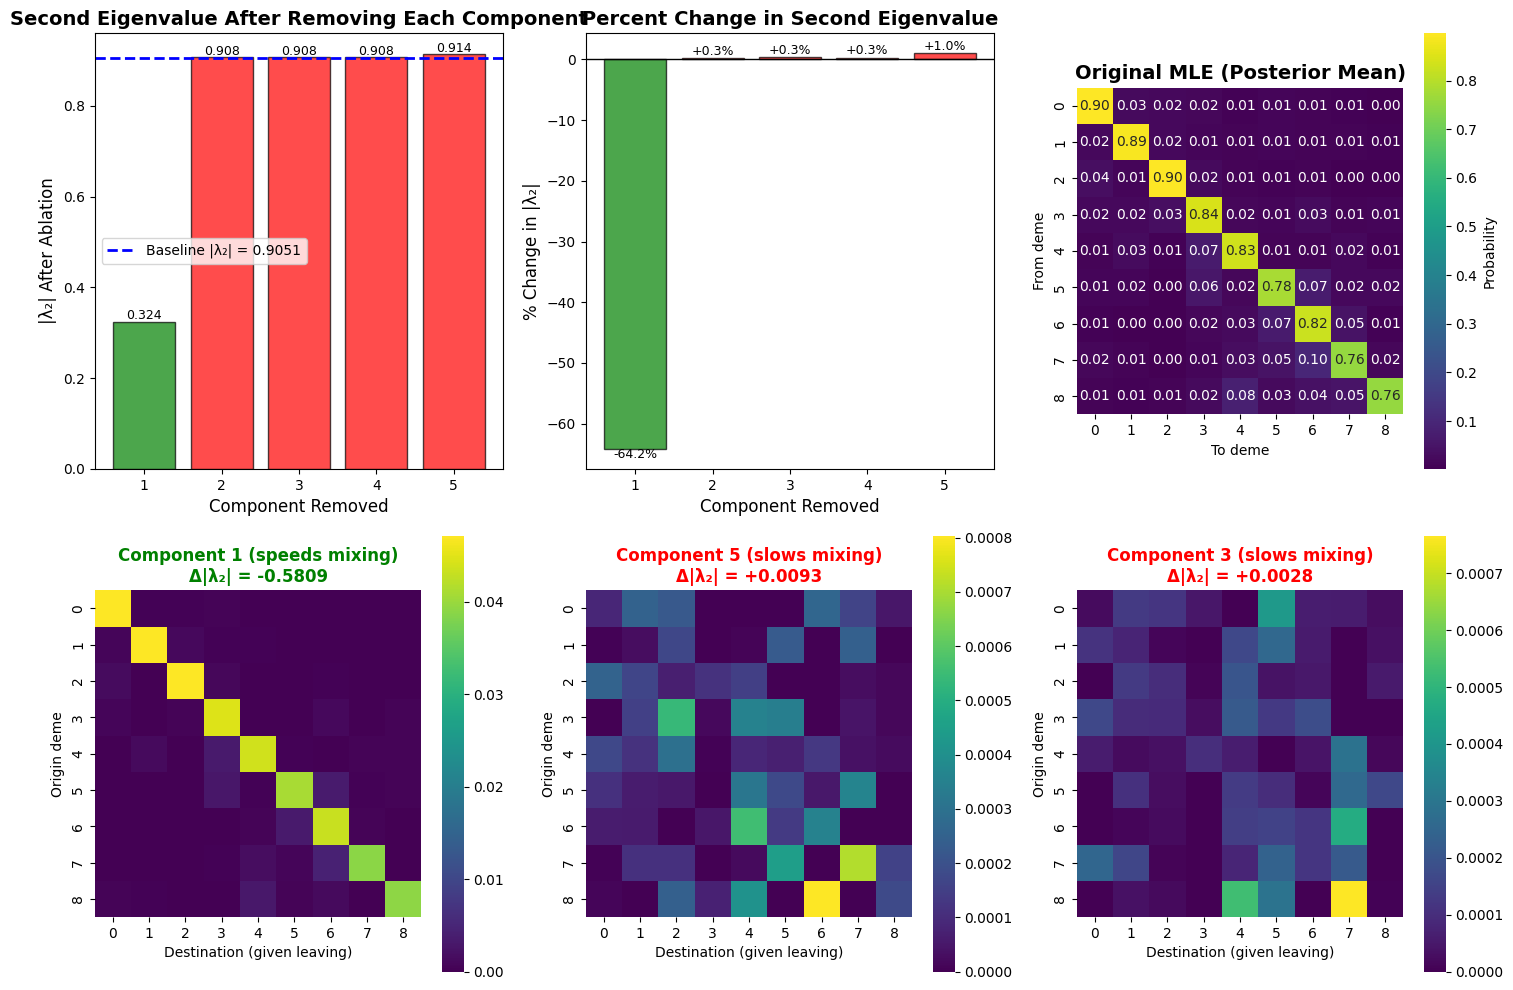

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# ----- Plot 1: Eigenvalue comparison bar chart -----
ax = axes[0, 0]
components = [r['component'] for r in ablation_results]
lambda2_values = [r['lambda2_ablated'] for r in ablation_results]
colors = ['red' if r['delta'] > 0 else 'green' for r in ablation_results]

bars = ax.bar(components, lambda2_values, color=colors, edgecolor='black', alpha=0.7)
ax.axhline(lambda2_baseline, color='blue', linestyle='--', linewidth=2, label=f'Baseline |λ₂| = {lambda2_baseline:.4f}')
ax.set_xlabel('Component Removed', fontsize=12)
ax.set_ylabel('|λ₂| After Ablation', fontsize=12)
ax.set_title('Second Eigenvalue After Removing Each Component', fontsize=14, fontweight='bold')
ax.legend()
ax.set_xticks(components)

# Add value labels
for bar, val in zip(bars, lambda2_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=9)

# ----- Plot 2: Percent change bar chart -----
ax = axes[0, 1]
pct_changes = [r['pct_change'] for r in ablation_results]
colors = ['red' if p > 0 else 'green' for p in pct_changes]

bars = ax.bar(components, pct_changes, color=colors, edgecolor='black', alpha=0.7)
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Component Removed', fontsize=12)
ax.set_ylabel('% Change in |λ₂|', fontsize=12)
ax.set_title('Percent Change in Second Eigenvalue', fontsize=14, fontweight='bold')
ax.set_xticks(components)

# Add value labels
for bar, val in zip(bars, pct_changes):
    ypos = bar.get_height() + 0.5 if val >= 0 else bar.get_height() - 1.5
    ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{val:+.1f}%', ha='center', fontsize=9)

# ----- Plot 3: Original MLE heatmap -----
ax = axes[0, 2]
sns.heatmap(A_mle, ax=ax, cmap='viridis', annot=True, fmt='.2f',
            square=True, cbar_kws={'label': 'Probability'})
ax.set_title('Original MLE (Posterior Mean)', fontsize=14, fontweight='bold')
ax.set_xlabel('To deme')
ax.set_ylabel('From deme')

# ----- Plots 4-6: Component patterns (top 3 by impact) -----
# Sort by absolute impact
sorted_results = sorted(ablation_results, key=lambda r: abs(r['delta']), reverse=True)

for idx, result in enumerate(sorted_results[:3]):
    ax = axes[1, idx]
    k = result['component'] - 1  # 0-indexed
    pattern = H[k].reshape(n_demes, n_demes)

    delta = result['delta']
    color = 'red' if delta > 0 else 'green'
    impact = "slows mixing" if delta > 0 else "speeds mixing"

    sns.heatmap(pattern, ax=ax, cmap='viridis', square=True, cbar=True)
    ax.set_title(f'Component {result["component"]} ({impact})\nΔ|λ₂| = {delta:+.4f}',
                 fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Destination (given leaving)')
    ax.set_ylabel('Origin deme')

plt.tight_layout()
plt.show()



In [ ]:
print(f"\nBaseline |λ₂| = {lambda2_baseline:.4f}")
print()

# Sort by impact
print("Components ranked by impact on mixing (most impactful first):")
print("-" * 60)
for r in sorted_results:
    k = r['component']
    delta = r['delta']
    pct = r['pct_change']

    if delta > 0.001:
        impact = "SLOWS mixing (removing it speeds things up)"
    elif delta < -0.001:
        impact = "SPEEDS mixing (removing it slows things down)"
    else:
        impact = "MINIMAL EFFECT on mixing"

    print(f"Component {k}: Δ|λ₂| = {delta:+.4f} ({pct:+.1f}%)")
    print(f"  → {impact}")
    print()

print("=" * 60)
print("INTERPRETATION GUIDE")
print("=" * 60)
print("""
|λ₂| close to 1 → Slow mixing (populations stay segregated longer)
|λ₂| close to 0 → Fast mixing (rapid homogenization)

If removing component k INCREASES |λ₂|:
  → That component was helping mixing (connecting demes)
  → It represents migration pathways that homogenize populations

If removing component k DECREASES |λ₂|:
  → That component was hindering mixing
  → It represents migration patterns that keep populations distinct
""")



Baseline |λ₂| = 0.9051

Components ranked by impact on mixing (most impactful first):
------------------------------------------------------------
Component 1: Δ|λ₂| = -0.5809 (-64.2%)
  → SPEEDS mixing (removing it slows things down)

Component 5: Δ|λ₂| = +0.0093 (+1.0%)
  → SLOWS mixing (removing it speeds things up)

Component 3: Δ|λ₂| = +0.0028 (+0.3%)
  → SLOWS mixing (removing it speeds things up)

Component 4: Δ|λ₂| = +0.0028 (+0.3%)
  → SLOWS mixing (removing it speeds things up)

Component 2: Δ|λ₂| = +0.0025 (+0.3%)
  → SLOWS mixing (removing it speeds things up)

INTERPRETATION GUIDE

|λ₂| close to 1 → Slow mixing (populations stay segregated longer)
|λ₂| close to 0 → Fast mixing (rapid homogenization)

If removing component k INCREASES |λ₂|:
  → That component was helping mixing (connecting demes)
  → It represents migration pathways that homogenize populations

If removing component k DECREASES |λ₂|:
  → That component was hindering mixing
  → It represents migration patte